<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/randfor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [2]:
df = pd.read_csv("adult.csv")

In [3]:
df.sample(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
5172,29,Private,201954,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,35,United-States,<=50K
12546,42,Local-gov,351161,Some-college,10,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
6251,35,Private,199288,11th,7,Separated,Transport-moving,Not-in-family,White,Male,0,0,90,United-States,<=50K
6681,50,Private,121685,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,>50K
21252,30,Private,323069,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,0,0,40,United-States,<=50K
8086,56,Private,184553,10th,6,Divorced,Craft-repair,Not-in-family,White,Male,0,0,56,United-States,<=50K
29551,22,Private,300871,Some-college,10,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,<=50K
14437,42,Local-gov,70655,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,44,United-States,<=50K
31013,20,Private,130840,10th,6,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,40,United-States,<=50K
15274,50,Federal-gov,221532,Assoc-acdm,12,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K


In [4]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


EDA


Uni

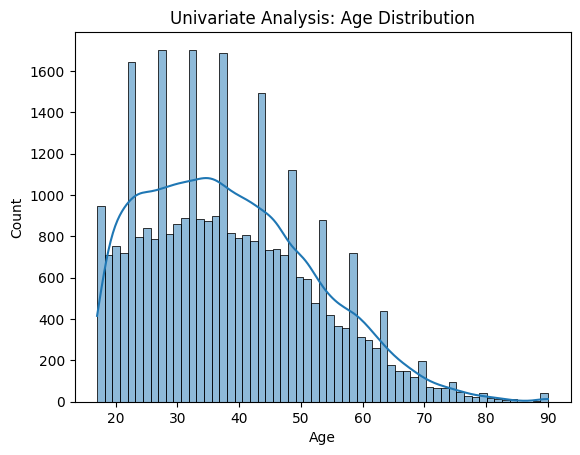

In [8]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Univariate Analysis: Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


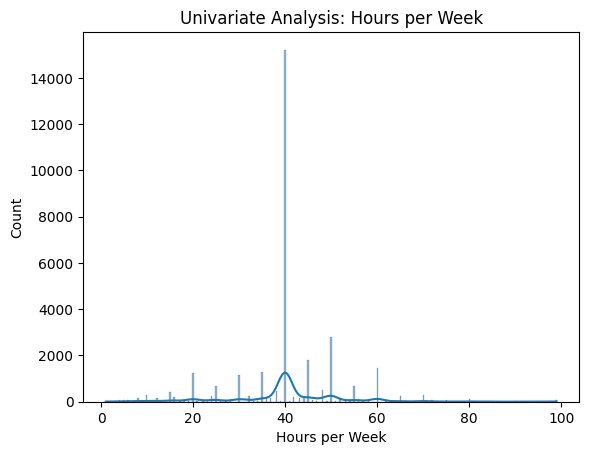

In [10]:
plt.figure()
sns.histplot(df['hours.per.week'], kde=True)
plt.title("Univariate Analysis: Hours per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Count")
plt.show()


bi

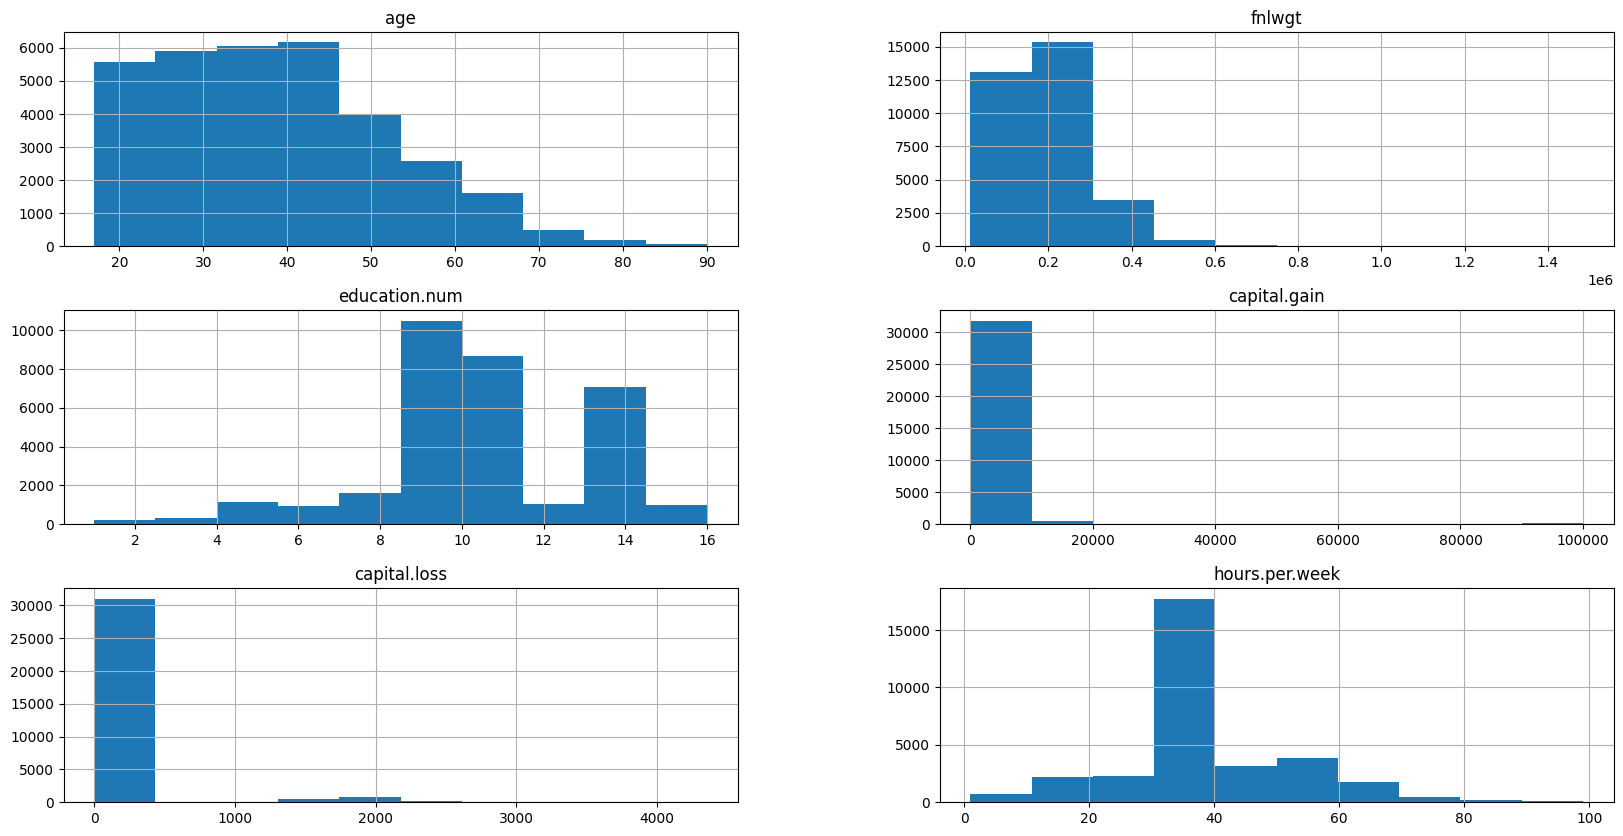

In [11]:
p= df.hist(figsize =(20,10))

multi

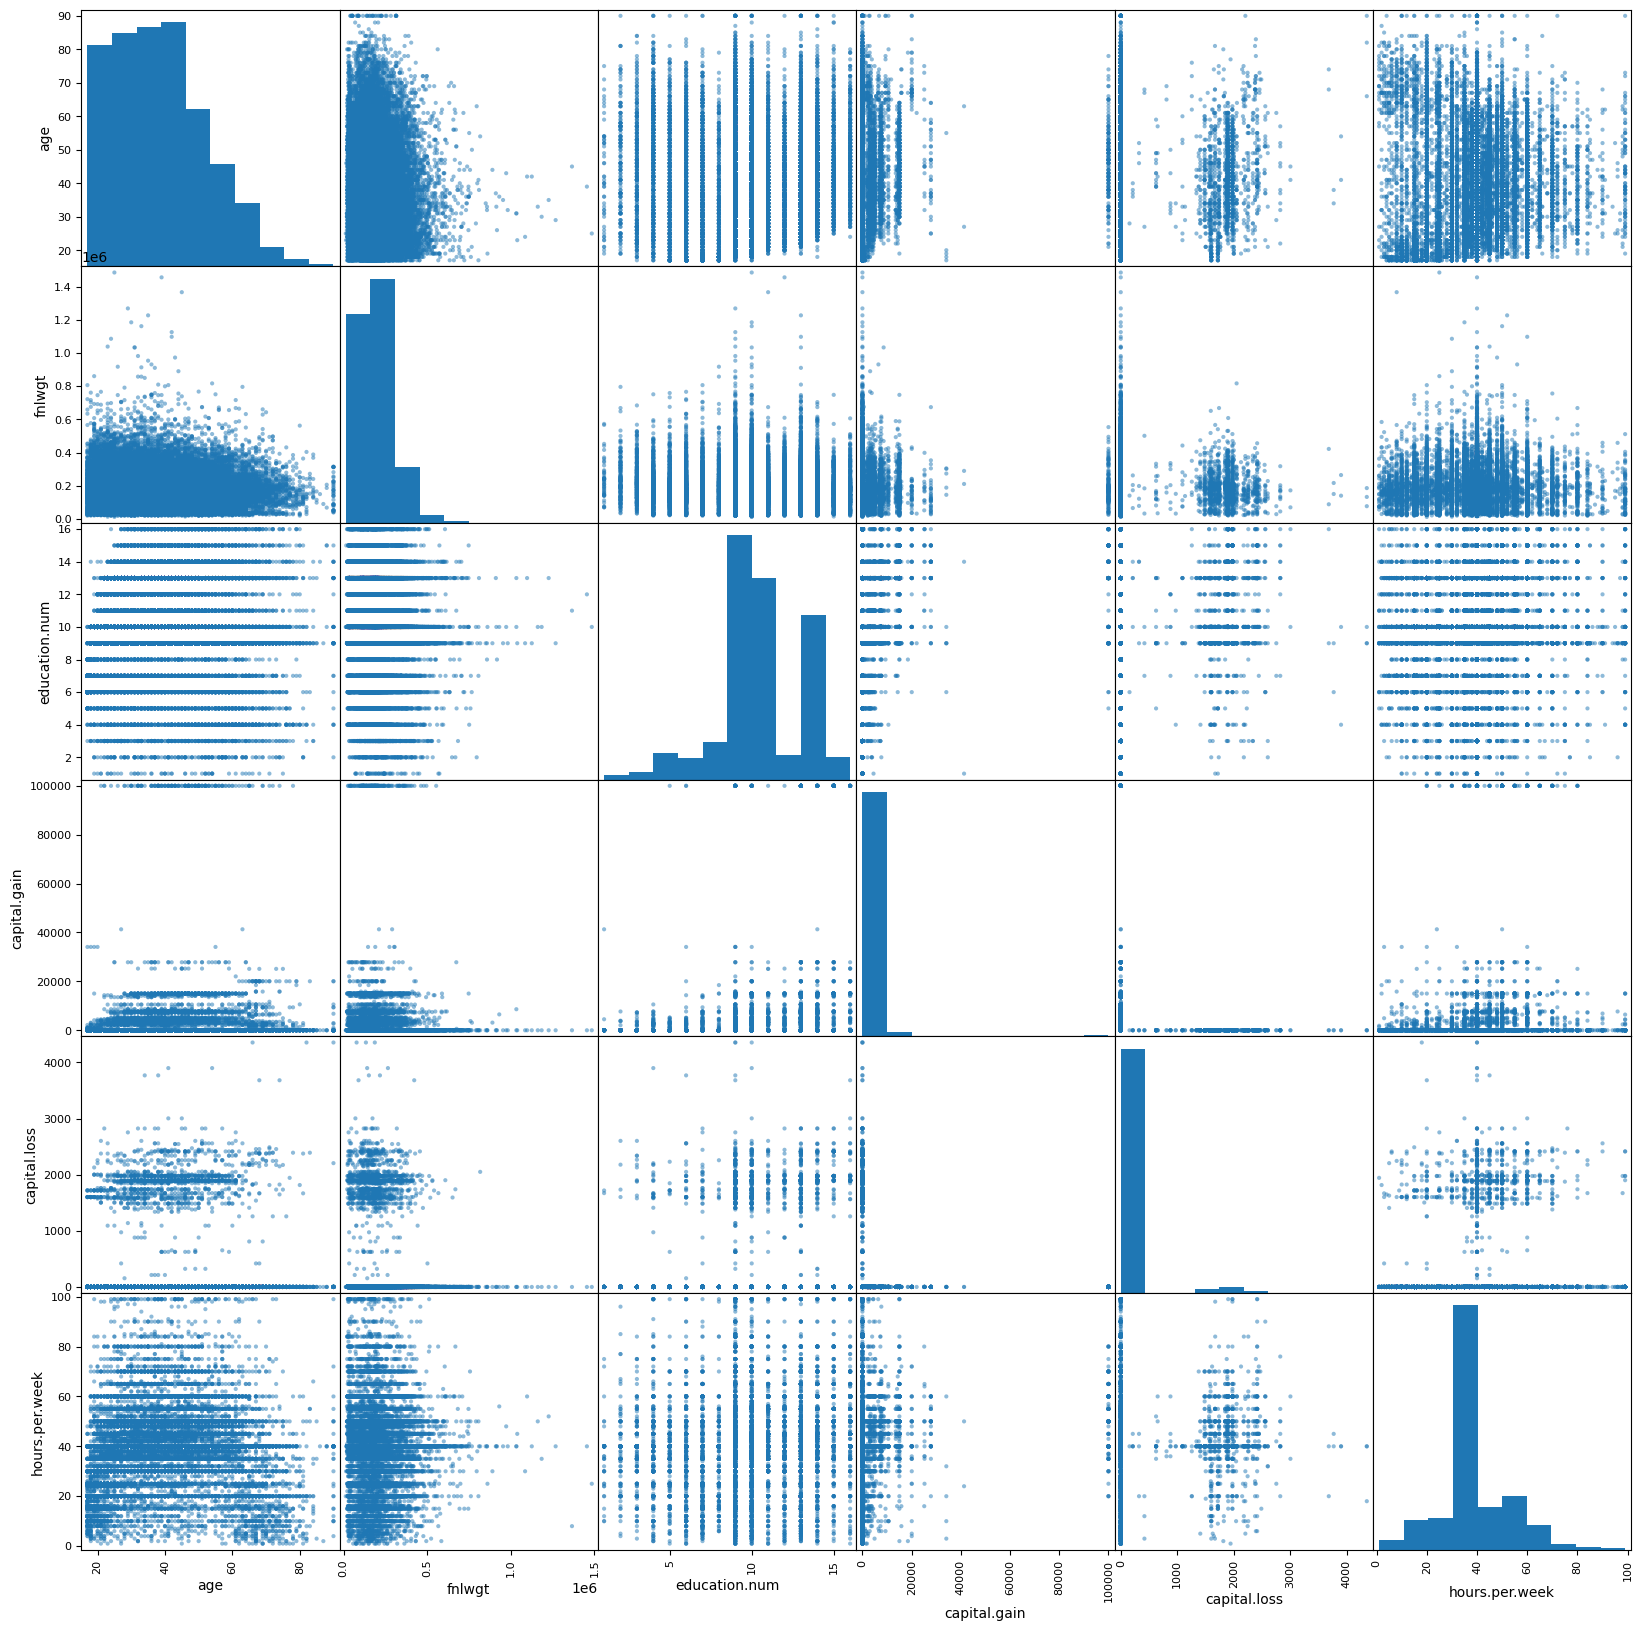

In [14]:
p = scatter_matrix(df,figsize=(20,20))

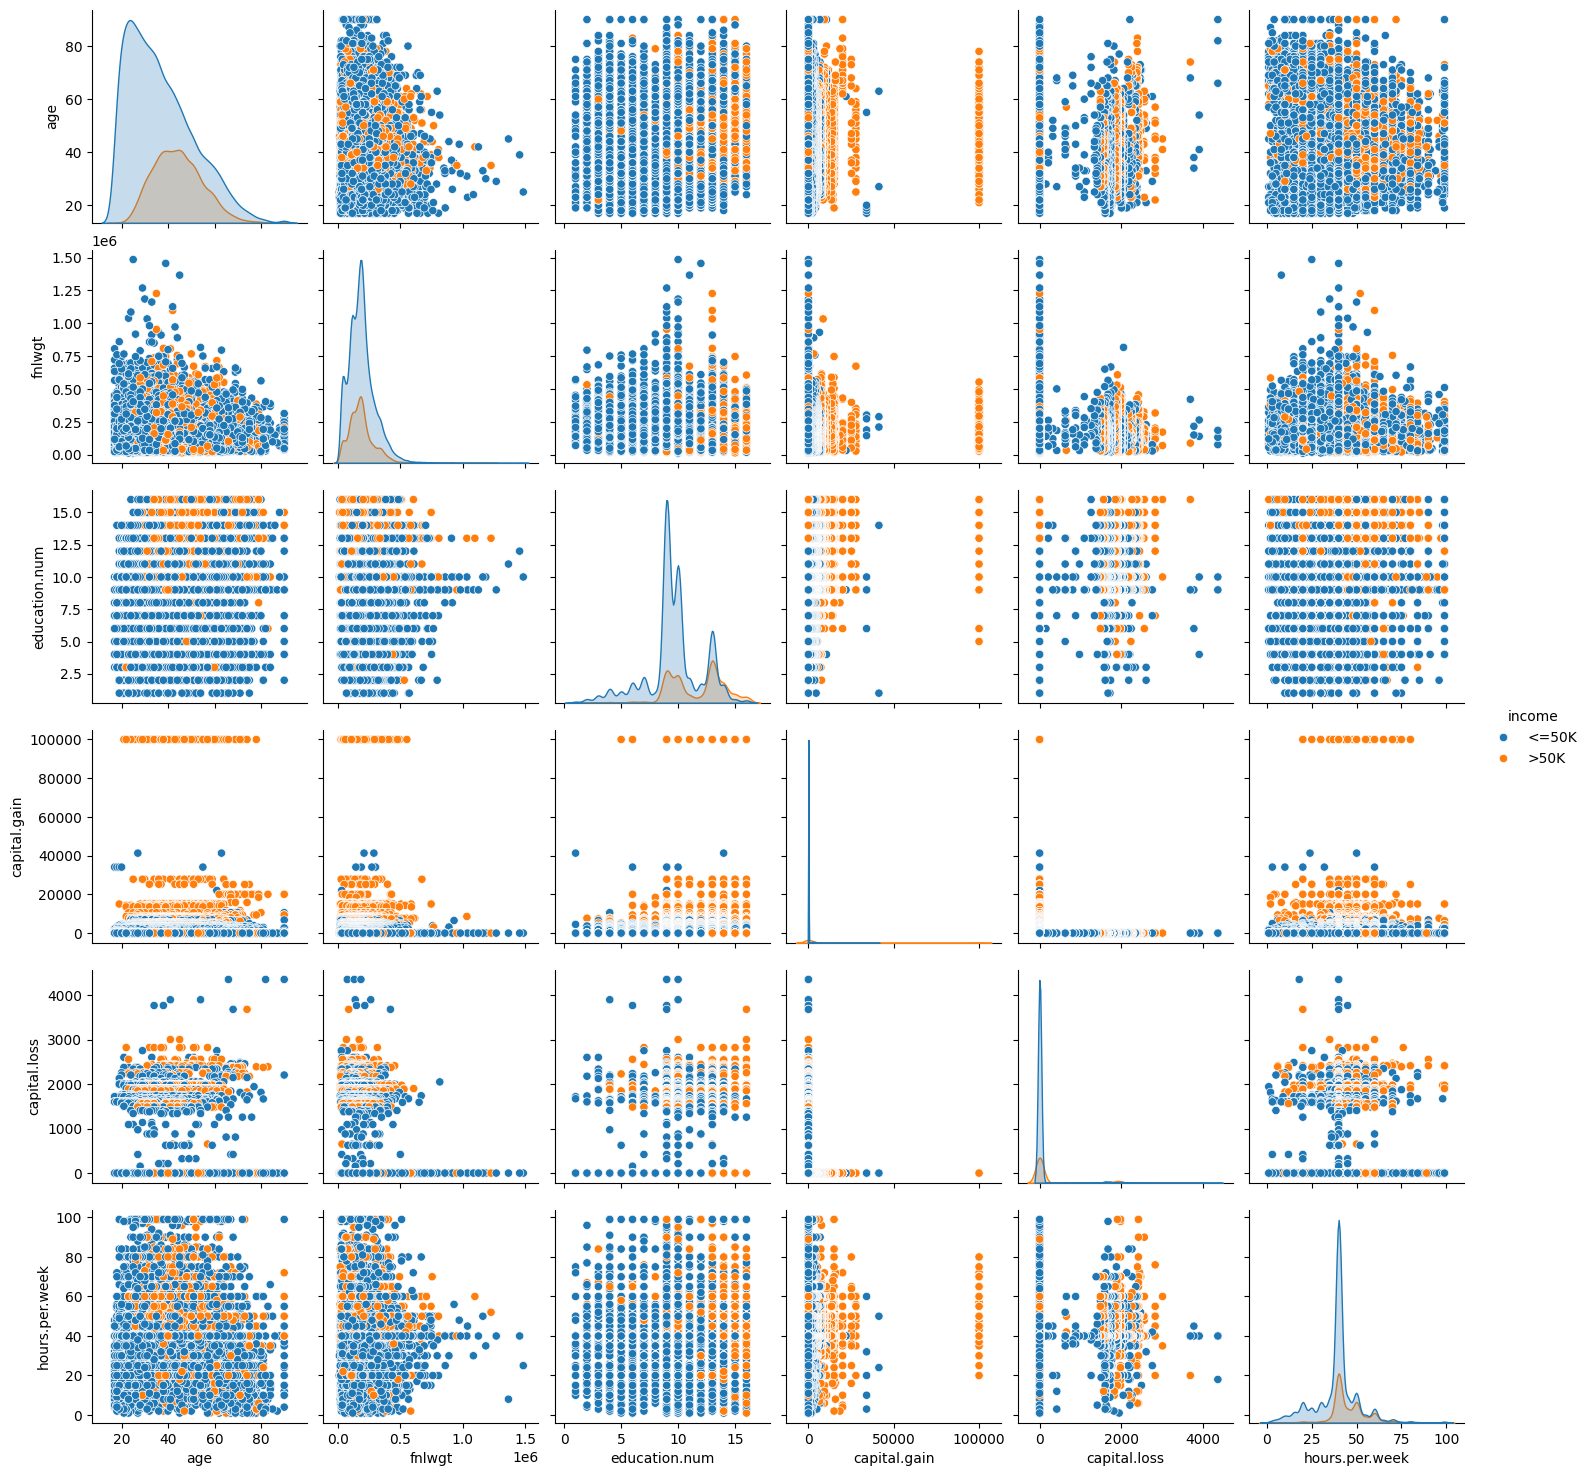

In [16]:
p = sns.pairplot(df,hue='income')

In [17]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.ensemble import RandomForestClassifier

# Settings
plt.style.use('default')
sns.set_context("notebook")


In [18]:
# Column names based on UCI Adult Dataset
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

# Display basic info
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [19]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Data types
df.info()

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Statistical summary (numerical)
df.describe()


Dataset Shape: (32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Missing Values:
 age               0
workclass         0
fnlwgt  

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [20]:
# Drop rows with missing values
df.dropna(inplace=True)

# Check after cleaning
print("After Cleaning Shape:", df.shape)


After Cleaning Shape: (32561, 15)


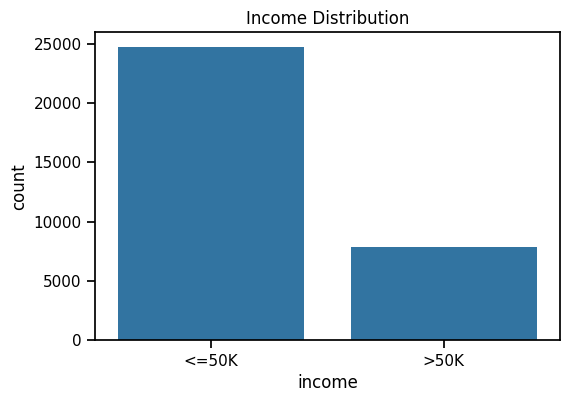

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()


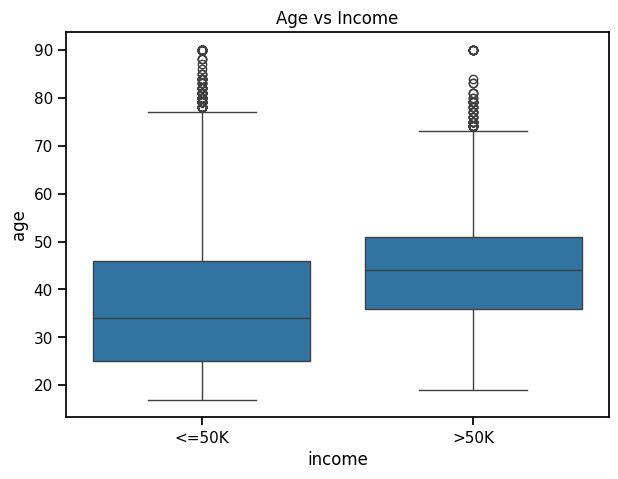

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(x="income", y="age", data=df)
plt.title("Age vs Income")
plt.show()


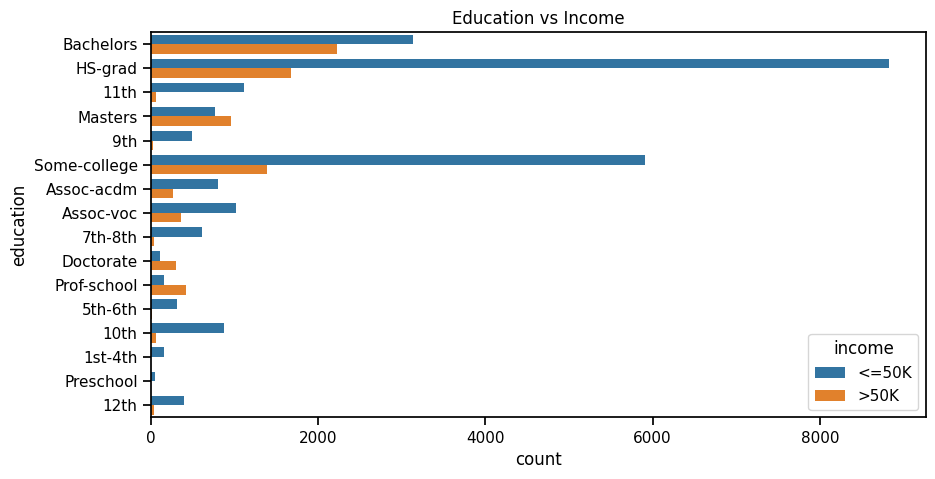

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(y="education", hue="income", data=df)
plt.title("Education vs Income")
plt.show()


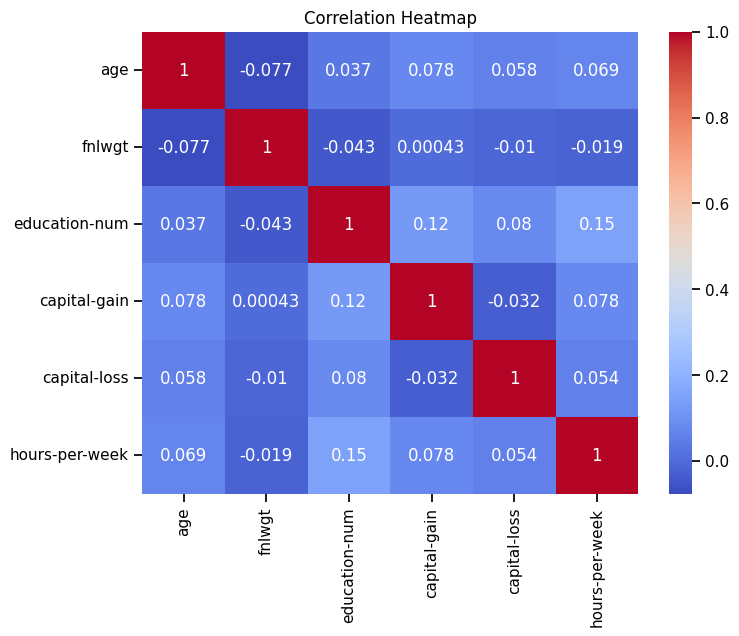

In [24]:
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [25]:
# Separate features and target
X = df.drop("income", axis=1)
y = df["income"]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)  # <=50K → 0, >50K → 1

# Identify categorical & numerical columns
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", LabelEncoder())  # will apply manually
])

# Encode categorical features
X_encoded = X.copy()
for col in categorical_cols:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)


Training Set: (26048, 14)
Testing Set: (6513, 14)


In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=12, n_jobs=-1, random_state=42)

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=12, n_jobs=-1, random_state=42)

In [29]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]


In [30]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8650391524643022


In [31]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      4945
        >50K       0.80      0.59      0.68      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.77      0.80      6513
weighted avg       0.86      0.87      0.86      6513



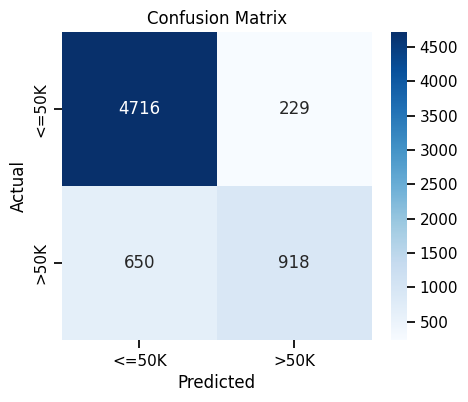

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


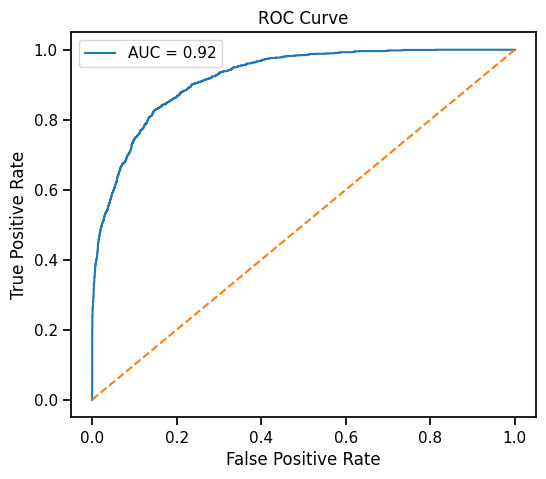

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


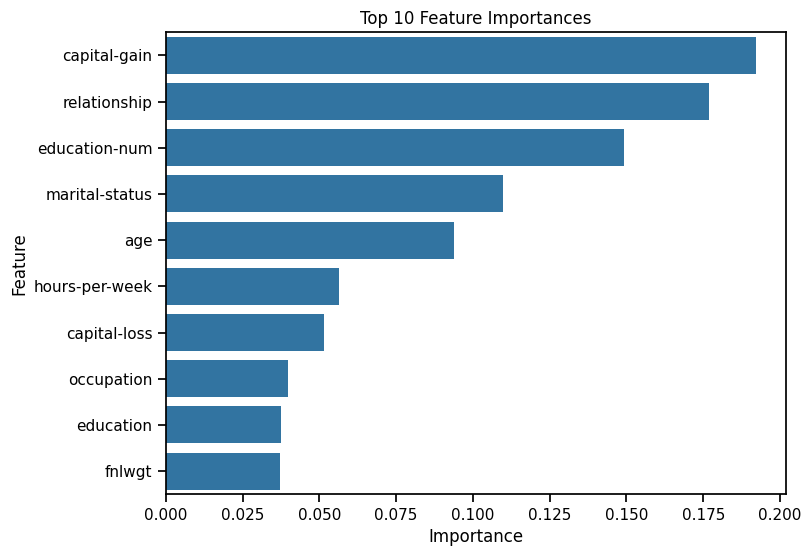

In [34]:
importances = rf_model.feature_importances_
features = X_encoded.columns

feature_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feature_imp.head(10))
plt.title("Top 10 Feature Importances")
plt.show()
